In [1]:
import numpy as np
import matplotlib.pyplot as plt

Example portfolio:

• A bank lends =C100,000 each to 10 firms.

• All firms promise to repay the full amount in one year (no interest, single payment).

• Each firm may default:

• Firm 1: 1% chance of default

• Firm 2: 2%

• . . .

• Firm 10: 10%

• If a firm defaults, it only repays =C50,000

⇒ the bank loses =C50,000




Simulation steps:

1. simulate default indicators

2. compute losses for each obligor

3. aggregate portfolio losses

4. repeat for many scenarios

5. analyse the (empirical) loss distribution -> draw a histogram


In [2]:
n_firmen        = 10
kredit_betrag   = 100_000
recovery_rate   = 0.50
verlust_je_def  = kredit_betrag * (1 - recovery_rate)

In [3]:
default_wkt = [i / 100 for i in range(1, n_firmen + 1)]

In [6]:
for i, p in enumerate(default_wkt, start=1):
    print(f"  Firma {i:2d}: Default-Wahrscheinlichkeit = {p*100:.0f} %")
print(f"\n  Verlust pro Default: {verlust_je_def:,.0f} €")
print(f"  Maximaler Gesamtverlust: {n_firmen * verlust_je_def:,.0f} €\n")

=== Portfolio-Setup ===
  Firma  1: Default-Wahrscheinlichkeit = 1 %
  Firma  2: Default-Wahrscheinlichkeit = 2 %
  Firma  3: Default-Wahrscheinlichkeit = 3 %
  Firma  4: Default-Wahrscheinlichkeit = 4 %
  Firma  5: Default-Wahrscheinlichkeit = 5 %
  Firma  6: Default-Wahrscheinlichkeit = 6 %
  Firma  7: Default-Wahrscheinlichkeit = 7 %
  Firma  8: Default-Wahrscheinlichkeit = 8 %
  Firma  9: Default-Wahrscheinlichkeit = 9 %
  Firma 10: Default-Wahrscheinlichkeit = 10 %

  Verlust pro Default: 50,000 €
  Maximaler Gesamtverlust: 500,000 €



In [7]:
rng = np.random.default_rng(seed=42)

n_szenarien = 100_000

zufallszahlen = rng.uniform(low=0.0, high=1.0, size=(n_szenarien, n_firmen))

default_wkt_arr = np.array(default_wkt)

default_matrix = zufallszahlen < default_wkt_arr

verlust_matrix = default_matrix * verlust_je_def

portfolio_verluste = verlust_matrix.sum(axis=1)


VaR Berechnung

In [14]:
konfidenzniveau = 0.99
var_99 = np.percentile(portfolio_verluste, konfidenzniveau * 100)
es_99  = portfolio_verluste[portfolio_verluste >= var_99].mean()

print(f"\n  VaR  (99 %)               : {var_99:>12,.0f} €")
print(f"  Expected shortfall (99 %) : {es_99:>12,.0f} €")



  VaR  (99 %)               :      150,000 €
  Expected shortfall (99 %) :      155,069 €


In [15]:
kein_verlust = (portfolio_verluste == 0).mean() * 100
print(f"\n  Szenarien ohne Verlust : {kein_verlust:.1f} %")


  Szenarien ohne Verlust : 56.4 %


**Histogramm der Verlustverteilung**

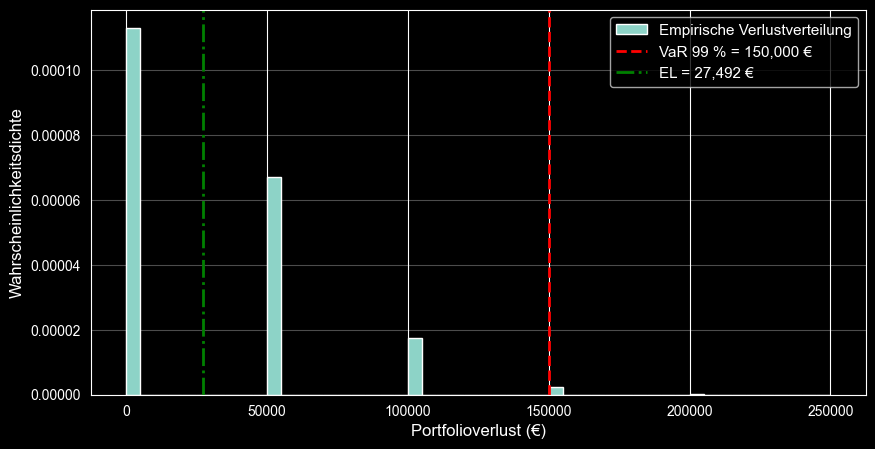

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    portfolio_verluste,
    bins=50,
    density=True,
    edgecolor="white",
    label="Empirische Verlustverteilung",
)

#VaR

ax.axvline(
    var_99,
    color="red",
    linewidth=2,
    linestyle="--",
    label=f"VaR 99 % = {var_99:,.0f} €",
)

#expected loss

ax.axvline(
    portfolio_verluste.mean(),
    color="green",
    linewidth=2,
    linestyle="-.",
    label=f"EL = {portfolio_verluste.mean():,.0f} €",
)

ax.set_xlabel("Portfolioverlust (€)", fontsize=12)
ax.set_ylabel("Wahrscheinlichkeitsdichte", fontsize=12)


ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.show()

